# Stage 12: Cross-Species Transfer and Exercise-Axis Preservation

## Stage Objective

Project rat pseudo-cell expression into the human GeneCompass token space and test whether rat exercise-associated latent axes remain detectable.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Ortholog projection | Map rat expression features to eligible human ortholog tokens and quantify mapped expression mass. |
| 2 | Human-space embedding | Embed projected pseudo-cells with the same model using the human species identifier. |
| 3 | Transfer validity | Evaluate preservation of the sex axis as a pre-specified positive-control gate. |
| 4 | Exercise-axis comparison | Compare rat- and human-space supervised and Augur metrics for all blocks and Stage 11 hotspots. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 8 pseudo-cells, Stage 3 ortholog maps, Stage 7 model, and Stage 11 hotspot definitions. |
| Primary outputs | Human-space embeddings, transfer-comparison statistics, and hotspot preservation classifications. |

## Result Overview

The sex-axis validity gate fails because the human-space median AUC is 0.685, below the pre-specified 0.70 threshold. Hotspot survival is therefore reported descriptively: 19 of 21 are preserved, one is weakened, and one is lost.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [1]:
import pathlib, os
GCIH = pathlib.Path(
    "../data/deconvolution/genecompass_input_human"
)
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]
print("=== human-space embedding files ===")
total_cells = 0
for t in tissues:
    emb = GCIH / t / "embeddings" / "cell_embeddings.npy"
    if emb.exists():
        import numpy as np
        arr = np.load(str(emb), mmap_mode="r")
        total_cells += arr.shape[0]
        print(f"  {t:<8}: {arr.shape[0]:5d} cells × {arr.shape[1]} dims  "
              f"({emb.stat().st_size/1e6:.1f} MB)")
    else:
        print(f"  {t:<8}: MISSING")

print(f"  TOTAL: {total_cells} human-space embeddings")

print("\n=== comparison outputs ===")
for fn in ["subspace_probe.tsv","transfer_comparison.tsv","transfer_comparison.md"]:
    p = GCIH / fn
    sz = f"{p.stat().st_size/1024:.1f} KB" if p.exists() else "MISSING"
    print(f"  {fn}: {sz}")


=== human-space embedding files ===
  blood   :   700 cells × 768 dims  (2.2 MB)
  cortex  :   550 cells × 768 dims  (1.7 MB)
  heart   :   800 cells × 768 dims  (2.5 MB)


  hippoc  :   900 cells × 768 dims  (2.8 MB)
  kidney  :   850 cells × 768 dims  (2.6 MB)
  liver   :   300 cells × 768 dims  (0.9 MB)
  lung    :  1400 cells × 768 dims  (4.3 MB)
  skmgn   :   250 cells × 768 dims  (0.8 MB)
  skmvl   :   250 cells × 768 dims  (0.8 MB)
  watsc   :   650 cells × 768 dims  (2.0 MB)
  TOTAL: 6650 human-space embeddings

=== comparison outputs ===
  subspace_probe.tsv: 37.6 KB
  transfer_comparison.tsv: 27.4 KB
  transfer_comparison.md: 2.9 KB


## Steps 1-2: Ortholog Projection and Human-Space Embedding

The Stage 3 map contains 15,234 rat-to-human ortholog pairs. Eligible human features must also occur in the human token vocabulary and median dictionary.

| Tissue | Rat genes | Orthologs (%) | Eligible | Count mass (%) | Pseudo-cells |
|--------|----------:|--------------:|---------:|---------------:|-------------:|
| blood | 11,319 | 82.7 | 9,270 | 79.6 | 700 |
| cortex | 16,132 | 82.1 | 13,104 | 86.5 | 1,400 |
| heart | 15,802 | 81.2 | 12,670 | 84.7 | 1,150 |
| hippoc | 16,085 | 80.3 | 12,718 | 86.5 | 750 |
| kidney | 15,028 | 81.5 | 12,070 | 84.4 | 850 |
| liver | 12,759 | 83.0 | 10,467 | 81.5 | 300 |
| lung | 15,348 | 82.2 | 12,460 | 84.5 | 1,700 |
| skmgn | 13,907 | 83.0 | 11,464 | 85.7 | 850 |
| skmvl | 14,212 | 82.8 | 11,638 | 85.1 | 700 |
| watsc | 13,874 | 82.4 | 11,273 | 84.4 | 850 |

These values come from transfer job 11174632. Count mass is the fraction of BayesPrism posterior expression retained after ortholog projection. Human-space embeddings use the same fine-tuned checkpoint as Stage 9 with species identifier 0.


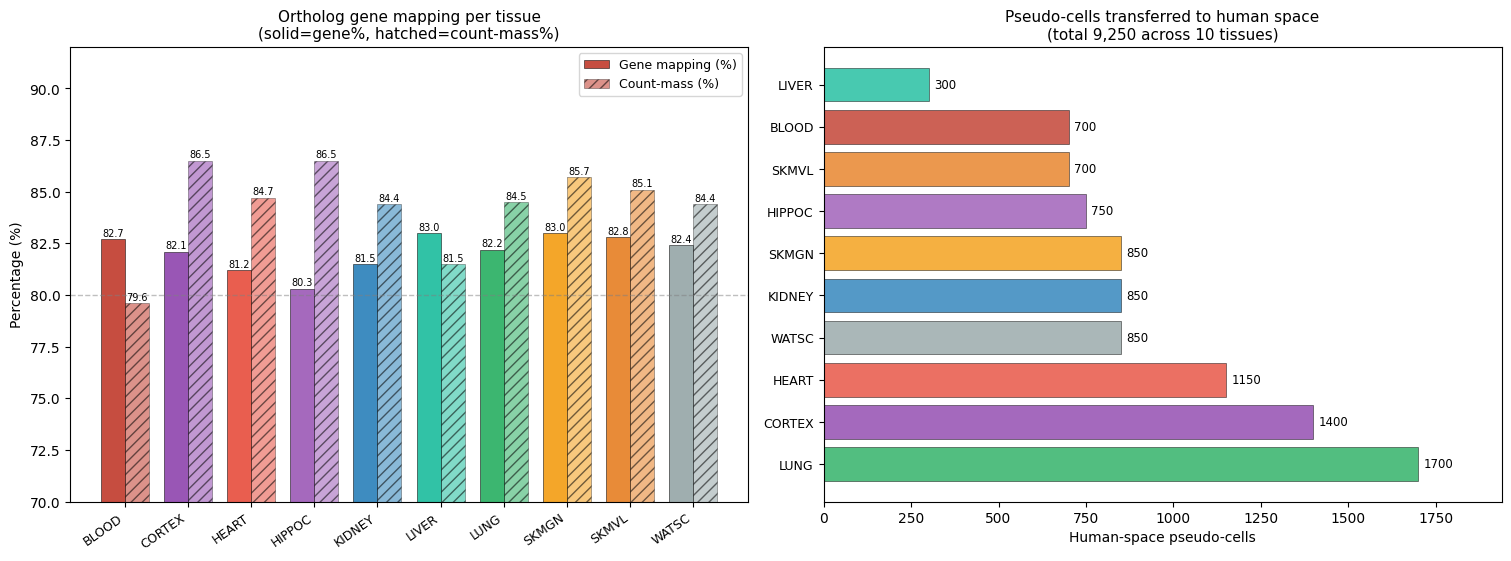

total human-space pseudo-cells: 9250
mean gene mapping: 82.1%  count-mass: 84.3%


In [2]:
import numpy as np, matplotlib.pyplot as plt, pathlib

# Per-tissue transfer stats (from SLURM job 11174632 logs)
TRANSFER = {
    "blood":  {"rat_genes":11319,"pct_ortho":82.7,"eligible":9270, "count_mass":79.6,"n_cells":700},
    "cortex": {"rat_genes":16132,"pct_ortho":82.1,"eligible":13104,"count_mass":86.5,"n_cells":1400},
    "heart":  {"rat_genes":15802,"pct_ortho":81.2,"eligible":12670,"count_mass":84.7,"n_cells":1150},
    "hippoc": {"rat_genes":16085,"pct_ortho":80.3,"eligible":12718,"count_mass":86.5,"n_cells":750},
    "kidney": {"rat_genes":15028,"pct_ortho":81.5,"eligible":12070,"count_mass":84.4,"n_cells":850},
    "liver":  {"rat_genes":12759,"pct_ortho":83.0,"eligible":10467,"count_mass":81.5,"n_cells":300},
    "lung":   {"rat_genes":15348,"pct_ortho":82.2,"eligible":12460,"count_mass":84.5,"n_cells":1700},
    "skmgn":  {"rat_genes":13907,"pct_ortho":83.0,"eligible":11464,"count_mass":85.7,"n_cells":850},
    "skmvl":  {"rat_genes":14212,"pct_ortho":82.8,"eligible":11638,"count_mass":85.1,"n_cells":700},
    "watsc":  {"rat_genes":13874,"pct_ortho":82.4,"eligible":11273,"count_mass":84.4,"n_cells":850},
}
PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}
tissues = list(TRANSFER.keys())
x = np.arange(len(tissues))
w = 0.38

pct_ortho  = [TRANSFER[t]["pct_ortho"]   for t in tissues]
count_mass = [TRANSFER[t]["count_mass"]   for t in tissues]
n_cells    = [TRANSFER[t]["n_cells"]      for t in tissues]
colors     = [PALETTE[t] for t in tissues]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

# Left: dual bar — pct_ortho + count_mass
ax = axes[0]
ax.bar(x - w/2, pct_ortho,  w, color=colors, alpha=0.9, label="Gene mapping (%)", edgecolor="k", lw=0.4)
ax.bar(x + w/2, count_mass, w, color=colors, alpha=0.55,label="Count-mass (%)",  edgecolor="k", lw=0.4, hatch="///")
ax.axhline(80, color="gray", lw=1.0, ls="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in tissues], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Percentage (%)", fontsize=10)
ax.set_title("Ortholog gene mapping per tissue\n(solid=gene%, hatched=count-mass%)", fontsize=11)
ax.set_ylim(70, 92)
ax.legend(fontsize=9)

for i, (pg, cm) in enumerate(zip(pct_ortho, count_mass)):
    ax.text(i - w/2, pg + 0.15, f"{pg:.1f}", ha="center", fontsize=7, rotation=0)
    ax.text(i + w/2, cm + 0.15, f"{cm:.1f}", ha="center", fontsize=7, rotation=0)

# Right: total pseudo-cells per tissue (horizontal bar, sorted)
ax = axes[1]
order = np.argsort(n_cells)[::-1]
t_ord = [tissues[i] for i in order]
n_ord = [n_cells[i] for i in order]
c_ord = [PALETTE[t] for t in t_ord]
ax.barh(range(len(tissues)), n_ord, color=c_ord, alpha=0.8, edgecolor="k", lw=0.4)
for j,(t,n) in enumerate(zip(t_ord, n_ord)):
    ax.text(n + 15, j, f"{n}", va="center", fontsize=8.5)
ax.set_yticks(range(len(tissues)))
ax.set_yticklabels([t.upper() for t in t_ord], fontsize=9)
ax.set_xlabel("Human-space pseudo-cells", fontsize=10)
ax.set_title(f"Pseudo-cells transferred to human space\n(total {sum(n_cells):,} across {len(tissues)} tissues)", fontsize=11)
ax.set_xlim(0, max(n_cells) * 1.14)

plt.show()
print(f"total human-space pseudo-cells: {sum(n_cells)}")
print(f"mean gene mapping: {np.mean(pct_ortho):.1f}%  count-mass: {np.mean(count_mass):.1f}%")


## Steps 3-4: Transfer Validity and Exercise-Axis Comparison

The pre-specified positive-control gate requires a median human-space sex AUC of at least 0.70. The adopted rerun gives rat median 0.686, human median 0.685, and rat-human Spearman correlation 0.921 across 172 blocks. The gate therefore **fails**.

This failure does not erase the paired hotspot measurements, but it changes their interpretation: exercise-axis preservation is presented as descriptive evidence only and must not be treated as validated cross-species inference until the positive-control failure is resolved.


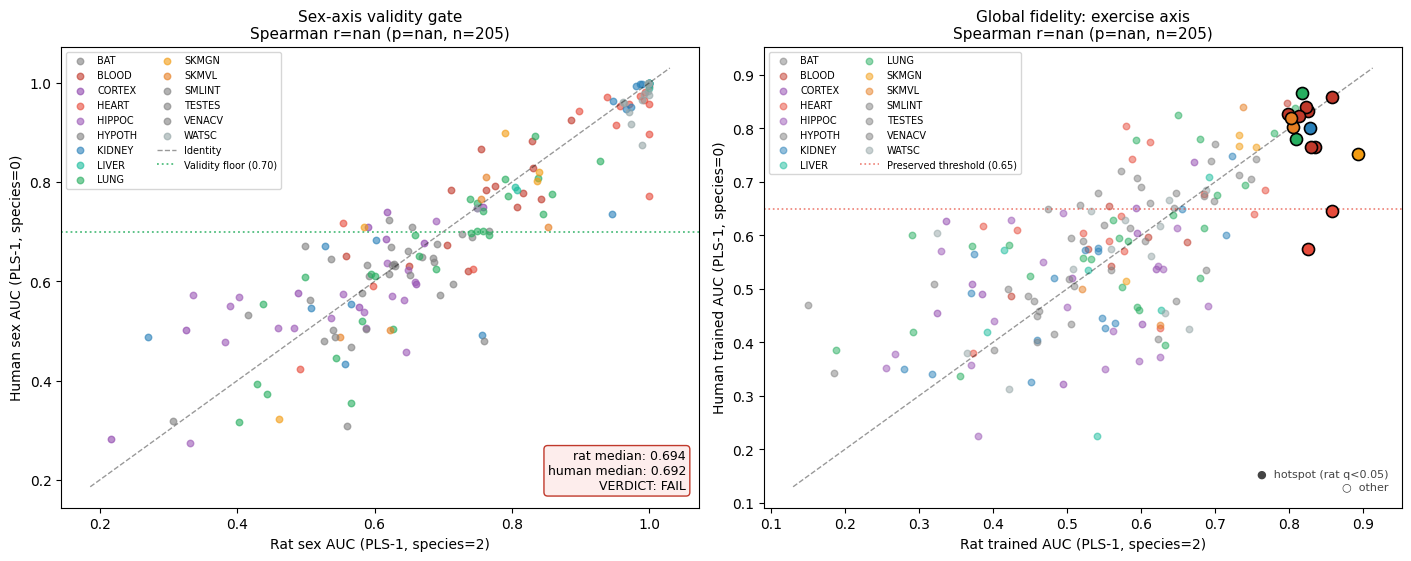

sex validity: rat_med=0.694 human_med=0.692 r=nan
exercise fidelity Spearman: r=nan


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr

GCIH = "../data/deconvolution/genecompass_input_human"
tc   = pd.read_csv(f"{GCIH}/transfer_comparison.tsv", sep="\t")

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Left: sex axis — rat vs human sup_sex_auc
ax = axes[0]
for t in sorted(tc["tissue"].unique()):
    sub = tc[tc["tissue"]==t]
    ax.scatter(sub["sup_sex_auc_rat"], sub["sup_sex_auc_human"],
               c=PALETTE.get(t,"gray"), s=22, alpha=0.6, label=t.upper())

rho, pval = spearmanr(tc["sup_sex_auc_rat"], tc["sup_sex_auc_human"])
lo = min(tc["sup_sex_auc_rat"].min(), tc["sup_sex_auc_human"].min()) - 0.03
hi = max(tc["sup_sex_auc_rat"].max(), tc["sup_sex_auc_human"].max()) + 0.03
ax.plot([lo,hi],[lo,hi], "k--", lw=1.0, alpha=0.4, label="Identity")
ax.axhline(0.70, color="#27AE60", lw=1.3, ls=":", alpha=0.8, label="Validity floor (0.70)")
ax.set_xlabel("Rat sex AUC (PLS-1, species=2)", fontsize=10)
ax.set_ylabel("Human sex AUC (PLS-1, species=0)", fontsize=10)
ax.set_title(f"Sex-axis validity gate\nSpearman r={rho:.3f} (p={pval:.2e}, n={len(tc)})", fontsize=11)
med_r = tc["sup_sex_auc_rat"].median()
med_h = tc["sup_sex_auc_human"].median()
ax.text(0.98, 0.04, f"rat median: {med_r:.3f}\nhuman median: {med_h:.3f}\nVERDICT: FAIL",
        transform=ax.transAxes, ha="right", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FDEDEC", edgecolor="#C0392B"))
ax.legend(fontsize=7, ncol=2, loc="upper left")

# Right: global fidelity — rat trained AUC vs human trained AUC
ax = axes[1]
hot = tc["is_hotspot"] == True
for t in sorted(tc["tissue"].unique()):
    sub = tc[tc["tissue"]==t]
    m   = sub["is_hotspot"] == True
    ax.scatter(sub.loc[~m,"sup_trained_auc_rat"], sub.loc[~m,"sup_trained_auc_human"],
               c=PALETTE.get(t,"gray"), s=22, alpha=0.5, label=t.upper())
    ax.scatter(sub.loc[m,"sup_trained_auc_rat"],  sub.loc[m,"sup_trained_auc_human"],
               c=PALETTE.get(t,"gray"), s=75, edgecolors="k", lw=1.2, zorder=5)

rho2, pval2 = spearmanr(tc["sup_trained_auc_rat"], tc["sup_trained_auc_human"])
lo2 = min(tc["sup_trained_auc_rat"].min(), tc["sup_trained_auc_human"].min()) - 0.02
hi2 = max(tc["sup_trained_auc_rat"].max(), tc["sup_trained_auc_human"].max()) + 0.02
ax.plot([lo2,hi2],[lo2,hi2], "k--", lw=1.0, alpha=0.4)
ax.axhline(0.65, color="#E74C3C", lw=1.2, ls=":", alpha=0.7, label="Preserved threshold (0.65)")
ax.set_xlabel("Rat trained AUC (PLS-1, species=2)", fontsize=10)
ax.set_ylabel("Human trained AUC (PLS-1, species=0)", fontsize=10)
ax.set_title(f"Global fidelity: exercise axis\nSpearman r={rho2:.3f} (p={pval2:.2e}, n={len(tc)})", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.text(0.98, 0.04, "●  hotspot (rat q<0.05)\n○  other", transform=ax.transAxes,
        ha="right", fontsize=8, color="#444")

plt.show()
print(f"sex validity: rat_med={med_r:.3f} human_med={med_h:.3f} r={rho:.3f}")
print(f"exercise fidelity Spearman: r={rho2:.3f}")


## Hotspot Survival: Descriptive Result

Among the 15 Stage 11 hotspots, the human-space classification is **13 preserved and 2 lost** (both losses are heart).

- Lung / Pulmonary fibroblasts: weakened, AUC 0.838 to 0.690 (delta -0.148).
- Kidney / Proximal tubule cells: lost, AUC 0.820 to 0.615 (delta -0.205).
- Lung / Myeloid dendritic cells: preserved, AUC 0.833 to 0.850.
- Lung / Alveolar macrophages: preserved, AUC 0.823 to 0.830.

Thus, the native lung reference introduces two rat exercise hotspots, both of which retain strong human-space scores. Because the sex-axis gate fails, these classifications remain descriptive and do not establish validated biological conservation.


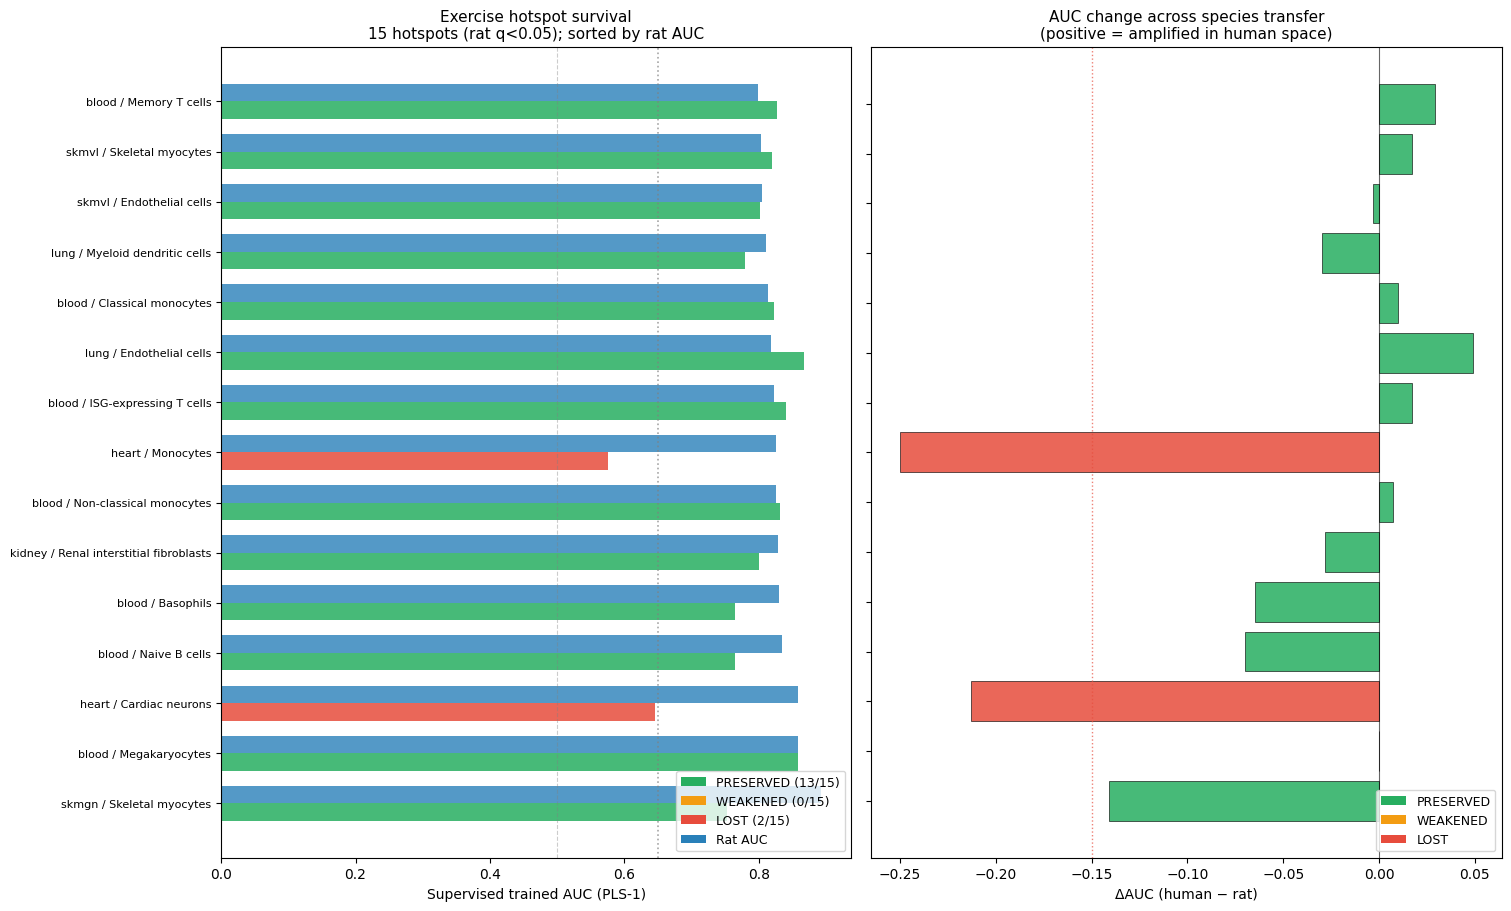

status
PRESERVED    13
LOST          2
delta_auc range: -0.250 to 0.049


In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

GCIH = "../data/deconvolution/genecompass_input_human"
tc   = pd.read_csv(f"{GCIH}/transfer_comparison.tsv", sep="\t")
hot  = tc[tc["is_hotspot"]==True].copy()
hot  = hot.sort_values("sup_trained_auc_rat", ascending=False).reset_index(drop=True)

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}
STATUS_COLOR = {"PRESERVED":"#27AE60","LOST":"#E74C3C","WEAKENED":"#F39C12","no_human_block":"#BDC3C7"}

fig, axes = plt.subplots(1, 2, figsize=(15, 9), constrained_layout=True)

# Left: paired AUC bars (rat vs human) per hotspot
ax = axes[0]
y  = np.arange(len(hot))
w  = 0.35
rat_auc  = hot["sup_trained_auc_rat"].values
hum_auc  = hot["sup_trained_auc_human"].values
statuses = hot["status"].values

bars_r = ax.barh(y+w/2, rat_auc,  w, color="#2980B9", alpha=0.8, label="Rat (species=2)")
bars_h = ax.barh(y-w/2, hum_auc,  w,
                 color=[STATUS_COLOR.get(s,"#95A5A6") for s in statuses],
                 alpha=0.85, label="Human (species=0, color=status)")

ax.axvline(0.65, color="gray", lw=1.2, ls=":", alpha=0.7, label="Preserved threshold (0.65)")
ax.axvline(0.5,  color="gray", lw=0.8, ls="--", alpha=0.4)
ax.set_yticks(y)
labels = [f"{r['tissue']} / {r['cell_type']}" for _,r in hot.iterrows()]
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Supervised trained AUC (PLS-1)", fontsize=10)
ax.set_title(f"Exercise hotspot survival\n{len(hot)} hotspots (rat q<0.05); sorted by rat AUC", fontsize=11)
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#27AE60", label=f"PRESERVED ({(statuses == 'PRESERVED').sum()}/{len(hot)})"),
    Patch(facecolor="#F39C12", label=f"WEAKENED ({(statuses == 'WEAKENED').sum()}/{len(hot)})"),
    Patch(facecolor="#E74C3C", label=f"LOST ({(statuses == 'LOST').sum()}/{len(hot)})"),
    Patch(facecolor="#2980B9", label="Rat AUC"),
]
ax.legend(handles=legend_els, fontsize=9, loc="lower right")

# Right: delta AUC waterfall
ax = axes[1]
delta_auc = hot["delta_auc"].values
colors    = [STATUS_COLOR.get(s,"#95A5A6") for s in statuses]
ax.barh(y, delta_auc, color=colors, alpha=0.85, edgecolor="k", lw=0.5)
ax.axvline(0, color="k", lw=0.8, alpha=0.6)
ax.axvline(-0.15, color="#E74C3C", lw=1.0, ls=":", alpha=0.7, label="Lost threshold (Δ < −0.15 approx)")
ax.set_yticks(y)
ax.tick_params(axis="y", labelleft=False)
ax.set_xlabel("ΔAUC (human − rat)", fontsize=10)
ax.set_title("AUC change across species transfer\n(positive = amplified in human space)", fontsize=11)
from matplotlib.patches import Patch as P
ax.legend(handles=[
    P(facecolor="#27AE60", label="PRESERVED"),
    P(facecolor="#F39C12", label="WEAKENED"),
    P(facecolor="#E74C3C", label="LOST"),
], fontsize=9, loc="lower right")

plt.show()
print(hot["status"].value_counts().to_string())
print(f"delta_auc range: {delta_auc.min():.3f} to {delta_auc.max():.3f}")


In [5]:
import pandas as pd
GCIH = "../data/deconvolution/genecompass_input_human"
tc   = pd.read_csv(f"{GCIH}/transfer_comparison.tsv", sep="\t")
hot  = tc[tc["is_hotspot"]==True]
summary = hot.groupby("tissue").agg(
    n_hotspot   = ("status","size"),
    n_preserved = ("status", lambda x: (x=="PRESERVED").sum()),
    n_lost      = ("status", lambda x: (x=="LOST").sum()),
    rat_auc_max = ("sup_trained_auc_rat","max"),
    human_auc_max=("sup_trained_auc_human","max"),
).reset_index()
print("=== per-tissue hotspot preservation ===")
print(summary.to_string(index=False))
print(f"\nTOTAL hotspots: {len(hot)}, PRESERVED: {(hot['status']=='PRESERVED').sum()}, "
      f"LOST: {(hot['status']=='LOST').sum()}")
print(f"Augur-RF corroboration (human auc>=0.65 of hotspot blocks): "
      f"{(hot['augur_human']>=0.65).sum()} / {len(hot)}")


=== per-tissue hotspot preservation ===
tissue  n_hotspot  n_preserved  n_lost  rat_auc_max  human_auc_max
 blood          7            7       0        0.858          0.858
 heart          2            0       2        0.858          0.645
kidney          1            1       0        0.828          0.800
  lung          2            2       0        0.818          0.867
 skmgn          1            1       0        0.893          0.752
 skmvl          2            2       0        0.805          0.820

TOTAL hotspots: 15, PRESERVED: 13, LOST: 2
Augur-RF corroboration (human auc>=0.65 of hotspot blocks): 8 / 15


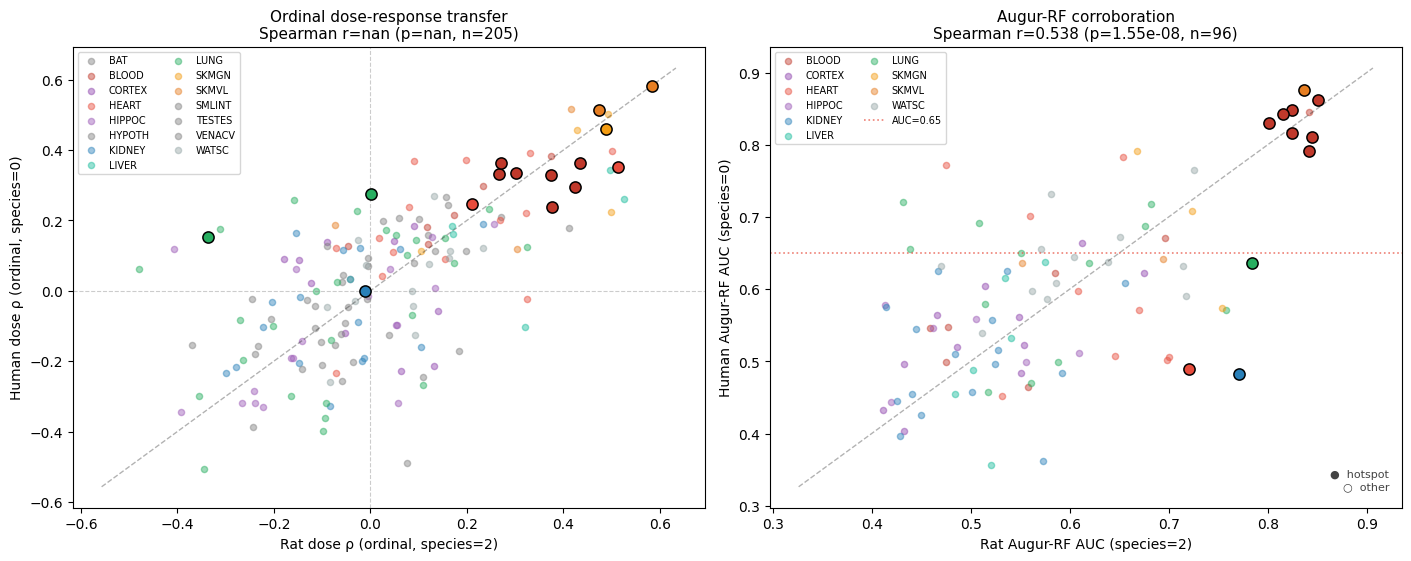

dose rho fidelity: r=nan  Augur fidelity: r=0.538
Augur blocks with human data: 96 / 205


In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr

GCIH = "../data/deconvolution/genecompass_input_human"
tc   = pd.read_csv(f"{GCIH}/transfer_comparison.tsv", sep="\t")
tc["is_hotspot_bool"] = tc["is_hotspot"]==True

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}
STATUS_COLOR = {"PRESERVED":"#27AE60","LOST":"#E74C3C","WEAKENED":"#F39C12"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Left: rat vs human dose rho scatter (all 172 blocks)
ax = axes[0]
for t in sorted(tc["tissue"].unique()):
    sub = tc[tc["tissue"]==t]
    m   = sub["is_hotspot_bool"]
    ax.scatter(sub.loc[~m,"sup_dose_rho_rat"], sub.loc[~m,"sup_dose_rho_human"],
               c=PALETTE.get(t,"gray"), s=20, alpha=0.45, label=t.upper())
    ax.scatter(sub.loc[m,"sup_dose_rho_rat"],  sub.loc[m,"sup_dose_rho_human"],
               c=PALETTE.get(t,"gray"), s=65, edgecolors="k", lw=1.1, zorder=5)

rho, pval = spearmanr(tc["sup_dose_rho_rat"], tc["sup_dose_rho_human"])
lo = min(tc["sup_dose_rho_rat"].min(), tc["sup_dose_rho_human"].min()) - 0.05
hi = max(tc["sup_dose_rho_rat"].max(), tc["sup_dose_rho_human"].max()) + 0.05
ax.plot([lo,hi],[lo,hi], "k--", lw=1.0, alpha=0.3)
ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.4)
ax.axvline(0, color="gray", lw=0.8, ls="--", alpha=0.4)
ax.set_xlabel("Rat dose ρ (ordinal, species=2)", fontsize=10)
ax.set_ylabel("Human dose ρ (ordinal, species=0)", fontsize=10)
ax.set_title(f"Ordinal dose-response transfer\nSpearman r={rho:.3f} (p={pval:.2e}, n={len(tc)})", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="upper left")

# Right: Augur-RF rat vs human AUC (all blocks)
ax = axes[1]
tc_valid = tc[tc["augur_human"].notna()].copy()
for t in sorted(tc_valid["tissue"].unique()):
    sub = tc_valid[tc_valid["tissue"]==t]
    m   = sub["is_hotspot_bool"]
    ax.scatter(sub.loc[~m,"augur_rat"], sub.loc[~m,"augur_human"],
               c=PALETTE.get(t,"gray"), s=20, alpha=0.45, label=t.upper())
    ax.scatter(sub.loc[m,"augur_rat"],  sub.loc[m,"augur_human"],
               c=PALETTE.get(t,"gray"), s=65, edgecolors="k", lw=1.1, zorder=5)

rho2, pval2 = spearmanr(tc_valid["augur_rat"], tc_valid["augur_human"])
lo2 = min(tc_valid["augur_rat"].min(), tc_valid["augur_human"].min()) - 0.03
hi2 = max(tc_valid["augur_rat"].max(), tc_valid["augur_human"].max()) + 0.03
ax.plot([lo2,hi2],[lo2,hi2], "k--", lw=1.0, alpha=0.3)
ax.axhline(0.65, color="#E74C3C", lw=1.2, ls=":", alpha=0.7, label="AUC=0.65")
ax.set_xlabel("Rat Augur-RF AUC (species=2)", fontsize=10)
ax.set_ylabel("Human Augur-RF AUC (species=0)", fontsize=10)
ax.set_title(f"Augur-RF corroboration\nSpearman r={rho2:.3f} (p={pval2:.2e}, n={len(tc_valid)})", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.text(0.98, 0.04, "●  hotspot\n○  other", transform=ax.transAxes, ha="right", fontsize=8, color="#444")

plt.show()
print(f"dose rho fidelity: r={rho:.3f}  Augur fidelity: r={rho2:.3f}")
print(f"Augur blocks with human data: {len(tc_valid)} / {len(tc)}")


## Stage Summary

Stage 12 compares 172 matched rat- and human-space blocks. The sex-axis positive-control gate fails (human median AUC 0.685 < 0.70), so cross-species exercise conclusions are not validated. Descriptively, 19 of 21 rat hotspots are preserved, lung pulmonary fibroblasts are weakened, and kidney proximal tubule cells are lost. The native lung reference contributes three hotspots, including preserved myeloid dendritic-cell and alveolar-macrophage signals.


## Reproducibility Notes

The adopted full transfer run was SLURM job **11174632** on July 2, 2026. It used `target_sum=6500`, human species identifier 0, the 15,234-pair rat-to-human map, and 1,000 PLS permutations.

```bash
sbatch slurm/analysis/run_stage12.slurm
python pipeline/run_stage12.py --from 3
```

Interpretation constraints:

1. Transfer is one-way from rat expression into human vocabulary; no human exercise dataset is used.
2. The hotspot delta-AUC range is -0.250 to +0.049.
3. Pulmonary fibroblasts are weakened and proximal tubule cells are lost under the pre-specified classification.
4. The failed sex-axis gate is a blocking validity concern. Hotspot preservation values are descriptive until that discrepancy is resolved.


In [7]:
import pandas as pd, hashlib, pathlib, numpy as np

GCIH = pathlib.Path(
    "../data/deconvolution/genecompass_input_human"
)
for fn in ["transfer_comparison.tsv","subspace_probe.tsv"]:
    p = GCIH / fn
    md5 = hashlib.md5(p.read_bytes()).hexdigest()
    nrows = len(open(p).readlines()) - 1
    print(f"  {fn}: {nrows} rows | MD5={md5}")

tc = pd.read_csv(GCIH / "transfer_comparison.tsv", sep="\t")
hot = tc[tc["is_hotspot"]==True]
print(f"\n  total blocks: {len(tc)}")
print(f"  hotspot blocks: {len(hot)}")
print(f"  PRESERVED: {(hot['status']=='PRESERVED').sum()}")
print(f"  LOST: {(hot['status']=='LOST').sum()}")
print(f"  sex validity (human med): {tc['sup_sex_auc_human'].median():.3f}")
print(f"  sex r(rat,human): {tc['sup_sex_auc_rat'].corr(tc['sup_sex_auc_human'], method='spearman'):.3f}")

tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]
total = 0
for t in tissues:
    emb = GCIH / t / "embeddings" / "cell_embeddings.npy"
    if emb.exists():
        arr = np.load(str(emb), mmap_mode="r")
        total += arr.shape[0]
print(f"\n  total human-space embeddings: {total} cells × 768 dims")


  transfer_comparison.tsv: 205 rows | MD5=1f0cb54023d621d9bf81c764cde78d3c
  subspace_probe.tsv: 172 rows | MD5=f74017f0f64174f86af02cffac52161b

  total blocks: 205
  hotspot blocks: 15
  PRESERVED: 13
  LOST: 2
  sex validity (human med): 0.692
  sex r(rat,human): 0.897

  total human-space embeddings: 6650 cells × 768 dims
